#### Importation

In [2]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

#### Chargement des jeux de données 

In [3]:
train_set = pd.read_csv("/home/arnaud/efrei/efrei_ml_crabs/data/train.csv")
test_set = pd.read_csv("/home/arnaud/efrei/efrei_ml_crabs/data/test.csv")

#### Exploration

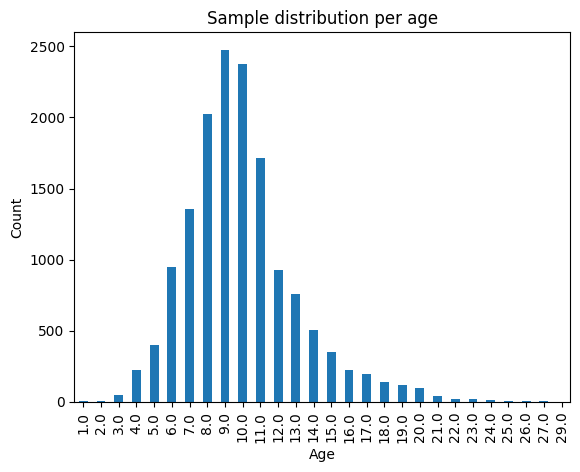

,id,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Age
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7499.500000,1.314114,1.021969,0.346207,23.207945,10.029359,5.011420,6.648089,9.922467
std,4330.271354,0.289515,0.238842,0.090708,12.618130,5.600515,2.794041,3.566568,3.196259
min,0.000000,0.275000,0.125000,0.000000,0.141747,0.070874,0.085048,0.085048,1.000000
25%,3749.750000,1.150000,0.875000,0.287500,13.168343,5.669900,2.778251,3.827183,8.000000
50%,7499.500000,1.375000,1.075000,0.362500,23.700182,9.893975,4.918638,6.803880,10.000000
75%,11249.250000,1.525000,1.200000,0.412500,32.134158,13.947954,6.959802,9.071840,11.000000
max,14999.000000,2.037500,1.950000,0.625000,78.797435,38.229301,18.228728,32.119983,29.000000


In [10]:
# x axis : age
# y axis : count
# histogram showing age distribution
import matplotlib.pyplot as plt

train_set['Age'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Sample distribution per age')
plt.show()
train_set.describe()

On remarque que la plupart des crabes du jeu de données ont entre 5 et 15 ans, cela risque de rendre le modèle moins précis sur cette population

#### Créations des matrices
On crée les matrices et vecteurs pour l'évaluation du modèle sur le jeu de données d'entrainement
On prépare la prédiction sur le test en créant x_test

In [5]:
x_train = train_set.drop(columns=["id", "Age"])
x_train = pd.get_dummies(x_train, columns=["Sex"])
x_train = x_train.values

y_train = train_set["Age"]
y_train = y_train.values

x_test = test_set.drop(columns=["id"])
x_test = pd.get_dummies(x_test, columns=["Sex"])
x_test = x_test.values

X_train, X_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42
)

print(f"Train : {X_train.shape[0]} exemples")
print(f"Val   : {X_val.shape[0]} exemples")

Train : 12000 exemples
Val   : 3000 exemples


In [18]:
from sklearn.utils import compute_sample_weight
model = Pipeline(    [
        ("scaler", StandardScaler()),
        ("regressor", LinearRegression()),
    ]
)

model.fit(X_train, y_train)
y_pred = model.predict(X_val)
mae = mean_absolute_error(y_val, y_pred)
print(f"MAE Locale : {mae:.4f}")

MAE Locale : 1.4180


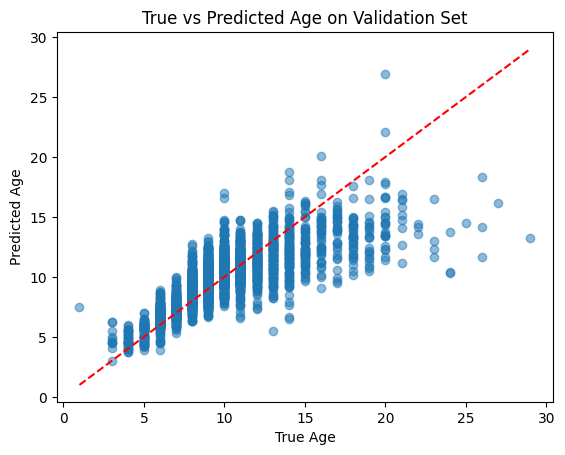

In [7]:
import matplotlib.pyplot as plt
plt.scatter(y_val, y_pred, alpha=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel("True Age")
plt.ylabel("Predicted Age")
plt.title("True vs Predicted Age on Validation Set")
plt.show()

In [24]:
predictions = model.predict(x_test)
submission = pd.DataFrame({"id": test_set["id"], "Age": predictions})
submission.to_csv("/home/arnaud/efrei/efrei_ml_crabs/submission.csv", index=False)

Bilan du modèle de régression linéaire : meilleure performance que la régression arbre de décision

In [ ]:
# import GradientBoostingRegressor
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_val)
mae = mean_absolute_error(y_val, y_pred)
print(f"MAE Locale : {mae:.4f}")

MAE Locale : 1.3684


In [37]:
import numpy as np
from lightgbm import LGBMRegressor
import lightgbm as lgb

model = LGBMRegressor(
    n_estimators=800,
    learning_rate=0.01,
    max_depth=7,
    num_leaves=31,
    subsample=0.7,
    colsample_bytree=0.9,
    random_state=42
)
# Option: log-transform target
model.fit(X_train, np.log1p(y_train),
          eval_set=[(X_val, np.log1p(y_val))],
          callbacks=[lgb.early_stopping(50)])
y_pred = np.expm1(model.predict(X_val))
mae = mean_absolute_error(y_val, y_pred)
print(f"MAE: {mae}")

        

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[627]	valid_0's l2: 0.0248385
MAE: 1.3329020672647998


/home/arnaud/efrei/efrei_ml_crabs/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [44]:
from xgboost import XGBRegressor
model = XGBRegressor(
        n_estimators=500,
    learning_rate=0.01,
    max_depth=7,
    subsample=0.7,
    colsample_bytree=0.9,
    random_state=42)
model.fit(X_train, np.log1p(y_train),
          eval_set=[(X_val, np.log1p(y_val))],)
y_pred = np.expm1(model.predict(X_val))
mae = mean_absolute_error(y_val, y_pred)
print(f"MAE: {mae}")

[0]	validation_0-rmse:0.28436
[1]	validation_0-rmse:0.28247
[2]	validation_0-rmse:0.28068
[3]	validation_0-rmse:0.27882
[4]	validation_0-rmse:0.27699
[5]	validation_0-rmse:0.27516
[6]	validation_0-rmse:0.27337
[7]	validation_0-rmse:0.27161
[8]	validation_0-rmse:0.26987
[9]	validation_0-rmse:0.26815
[10]	validation_0-rmse:0.26655
[11]	validation_0-rmse:0.26489
[12]	validation_0-rmse:0.26326
[13]	validation_0-rmse:0.26164
[14]	validation_0-rmse:0.26005
[15]	validation_0-rmse:0.25846
[16]	validation_0-rmse:0.25688
[17]	validation_0-rmse:0.25535
[18]	validation_0-rmse:0.25389
[19]	validation_0-rmse:0.25238
[20]	validation_0-rmse:0.25089
[21]	validation_0-rmse:0.24944
[22]	validation_0-rmse:0.24800
[23]	validation_0-rmse:0.24666
[24]	validation_0-rmse:0.24525
[25]	validation_0-rmse:0.24387
[26]	validation_0-rmse:0.24259
[27]	validation_0-rmse:0.24124
[28]	validation_0-rmse:0.23997
[29]	validation_0-rmse:0.23866
[30]	validation_0-rmse:0.23736
[31]	validation_0-rmse:0.23611
[32]	validation_0-